In [19]:
import json
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.preprocessing import StandardScaler

with open('cresci-stock-2018_tweets.json', 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

# etykiety
labels_df = pd.read_csv(
    'cresci-stock-2018.tsv',
    sep='\t',
    header=None,
    names=['id', 'label']
)

label_map = {'human': 0, 'bot': 1}
labels_df['target'] = labels_df['label'].map(label_map)

# ekstrakcja danych o użytkowniku
def extract_user_data(record):
    user_info = record['user']
    return user_info

user_data_list = [extract_user_data(record) for record in raw_data]
df_users = pd.DataFrame(user_data_list)

df_users['id'] = df_users['id'].astype(str)
labels_df['id'] = labels_df['id'].astype(str)
df_merged = df_users.merge(labels_df[['id', 'target']], on='id')



In [8]:
df_users['id'].nunique()

13276

![image.png](attachment:image.png)

![image1.png](attachment:image1.png)

używam rozszerzenia Data Wrangler do przejrzenia dataframe'a w wygodnej formie, sceenshoty są w plikach image.png i image1.png.
Na podstawie podsumowań każdej kolumny od razu wybieram zmienne do usunięcia, które mają za mało distinct wartości (za mala zmienność) albo nie mają sensu do uzycia do ML - np kolumny z ID.

* do usuniecia po obejrzeniu danych:
* id,
* id_str,
* name,
* screen_name,
* entities (dubluje informacje z kolumny url),
* protected (0 zmiennosci, 100% danych ma False),
* utc_offset (100% missing),
* time_zone (100% missing),
* verified (99% False),
* contributors_enabled (100% false),
* is_translator (100% False),
* is_translation_enabled (99% False),
* profile_image_url,
* profile_image_url_https,
* default_profile_image (99% false),
* following (100% false),
* follow_request_sent (100% false),
* notifications (100% false),
* translator_type (99% none)


In [20]:
columns_to_drop = [
    'id',
    'id_str',
    'name',
    'screen_name',
    'entities',
    'protected',
    'utc_offset',
    'time_zone',
    'verified',
    'contributors_enabled',
    'is_translator',
    'is_translation_enabled',
    'profile_image_url',
    'profile_image_url_https',
    'profile_background_image_url_https',
    'default_profile_image',
    'following',
    'follow_request_sent',
    'notifications',
    'translator_type'
]

df_cleaned = df_merged.drop(columns=columns_to_drop, errors='ignore')


In [21]:
#Tworzenie deterministycznych cech - wartosci wynikaja bezposrednio z pojedynczej obserwacji, nie ma porownan do rozkladu calego datasetu
df_cleaned['has_description'] = df_cleaned['description'].astype(bool).astype(int)

df_cleaned['has_location'] = df_cleaned['location'].str.strip().apply(lambda x: 0 if x == '' else 1)

df_cleaned['has_default_bg_theme'] = df_cleaned['profile_background_image_url'].apply(
    lambda x: 0 if 'theme1/bg.png' in str(x) else 1)

df_cleaned['geo_enabled'] = df_cleaned['geo_enabled'].astype(int)

df_cleaned['profile_background_tile'] = df_cleaned['profile_background_tile'].astype(int)

df_cleaned['profile_use_background_image'] = df_cleaned['profile_use_background_image'].astype(int)

df_cleaned['default_profile'] = df_cleaned['default_profile'].astype(int)

df_cleaned['has_extended_profile'] = df_cleaned['has_extended_profile'].astype(int)

df_cleaned['has_added_url'] = df_cleaned['url'].apply(lambda x: 1 if pd.notna(x) and str(x).strip() != '' else 0)
df_cleaned['has_profile_banner'] = df_merged['profile_banner_url'].notnull().astype(int)

df_cleaned['user_created_at'] = pd.to_datetime(df_cleaned['created_at'],errors='coerce').dt.tz_localize(None)
df_cleaned['account_age_days'] = (pd.Timestamp('2017-09-30') - df_cleaned['user_created_at']).dt.days

/tmp/ipykernel_776/444091878.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_cleaned['user_created_at'] = pd.to_datetime(df_cleaned['created_at'],errors='coerce').dt.tz_localize(None)


In [22]:
print(df_cleaned['target'].value_counts())

target
1    7102
0    6174
Name: count, dtype: int64


In [23]:
#train test split - moje klasy są już zbalansowane (47%/53% więc nie robiłam downsamplingu ani oversamplingu)
X = df_cleaned.drop(columns=['target'])
y = df_cleaned['target']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

In [24]:
#Po splicie tylko bazujac na statystykach z train setu robie pozostale cechy:

# Wyznaczenie najczęstszych kategorii wyłącznie na train secie

top_profile_text_colors = X_train['profile_text_color'].value_counts().nlargest(2).index.tolist()

top_sidebar_colors = X_train['profile_sidebar_fill_color'].value_counts().nlargest(3).index.tolist()

top_sidebar_border_colors = X_train['profile_sidebar_border_color'].value_counts().nlargest(3).index.tolist()

top_profile_link_colors = X_train['profile_link_color'].value_counts().nlargest(2).index.tolist()

top_profile_background_colors = X_train['profile_background_color'].value_counts().nlargest(3).index.tolist()

top_lang = X_train['lang'].value_counts().nlargest(3).index.tolist()


#utworzenie cech osobno na train i test secie

X_train['profile_text_color_cat'] = X_train['profile_text_color'].apply(
    lambda x: x if x in top_profile_text_colors else 'other'
)

X_train['sidebar_fill_color_cat'] = X_train['profile_sidebar_fill_color'].apply(
    lambda x: x if x in top_sidebar_colors else 'other'
)

X_train['sidebar_border_color_cat'] = X_train['profile_sidebar_border_color'].apply(
    lambda x: x if x in top_sidebar_border_colors else 'other'
)

X_train['profile_link_color_cat'] = X_train['profile_link_color'].apply(
    lambda x: x if x in top_profile_link_colors else 'other'
)

X_train['profile_background_color_cat'] = X_train['profile_background_color'].apply(
    lambda x: x if x in top_profile_background_colors else 'other'
)

X_train['lang_cat'] = X_train['lang'].apply(
    lambda x: x if x in top_lang else 'other'
)


#test set
X_test['profile_text_color_cat'] = X_test['profile_text_color'].apply(
    lambda x: x if x in top_profile_text_colors else 'other'
)

X_test['sidebar_fill_color_cat'] = X_test['profile_sidebar_fill_color'].apply(
    lambda x: x if x in top_sidebar_colors else 'other'
)

X_test['sidebar_border_color_cat'] = X_test['profile_sidebar_border_color'].apply(
    lambda x: x if x in top_sidebar_border_colors else 'other'
)

X_test['profile_link_color_cat'] = X_test['profile_link_color'].apply(
    lambda x: x if x in top_profile_link_colors else 'other'
)

X_test['profile_background_color_cat'] = X_test['profile_background_color'].apply(
    lambda x: x if x in top_profile_background_colors else 'other'
)

X_test['lang_cat'] = X_test['lang'].apply(
    lambda x: x if x in top_lang else 'other'
)


In [25]:
#Eksperymentuję z feature engineeringiem:
X_train['followers_friends_ratio'] = X_train['followers_count'] / (X_train['friends_count'] + 1)

X_train['tweets_per_day'] = X_train['statuses_count'] / (X_train['account_age_days'] + 1)

X_train['favourites_per_day'] = X_train['favourites_count'] / (X_train['account_age_days'] + 1)

In [26]:
#drop kolumn z których byly robione zmienne
columns_to_drop_2 = [
    'description',
    'user_created_at',
    'created_at',
    'location',
    'url' ,
    'lang',
    'profile_background_image_url',
    'profile_banner_url',
    'profile_text_color',
    'profile_sidebar_fill_color',
    'profile_sidebar_border_color',
    'profile_link_color',
    'profile_background_color' ]

X_train = X_train.drop(columns=columns_to_drop_2)
X_test = X_test.drop(columns=columns_to_drop_2)

In [15]:



'''ogladam tak wyczyszczony dataset w Data Wrangler: image2.png i image3.png
generuję raport o statystykach każdej zmiennej i korelajach z biblioteki ydata-profiling.
Nie uruchamiam tu kodu do generowania, ponieważ biblioteka nie obsługuje Pythona 3.14 którego mam lokalnie,
więc wygenerowałam raport w Google Colab. Jest załączony jako plik html.

Kod do wygenerowania raportu: '''

!pip install ydata-profiling
from ydata_profiling import ProfileReport

profile = ProfileReport(
    X_train,
    explorative=False,
    minimal=True,
    correlations={
        "pearson": {"calculate": True},
        "spearman": {"calculate": False},
        "kendall": {"calculate": False},
        "phi_k": {"calculate": True},
        "cramers": {"calculate": True}
    },
    vars={"num": {"low_categorical_threshold": 0}}
)

profile.to_file("korelacje_male.html")

from google.colab import files
files.download("korelacje_male.html")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.8 MB/s eta 0:00:00


/tmp/ipykernel_776/3841656295.py:9: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 25/25 [00:00<00:00, 59.98it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

![image.png](attachment:image.png)

Ponieważ mam różne typy zmiennych i interesuje mnie różny rodzaj korelacji (nie tylko liniowa) oglądam macierz i tabelę statystyki Phik. Większość zmiennych nie jest skorelowana, ale widać mocne korelacje przy zmiennych kategorycznych kolorów profilu. Bardzo wysoka wartość Phik dla par tych zmiennych i zmiennej "default profile". Usunę zmienne mówiące o kolorach elementow profilu, a zostawię zmienną default profile, bo jest najbardziej ogólna.

In [27]:
columns_to_drop = [
    'listed_count',
    'profile_text_color_cat',
    'sidebar_fill_color_cat',
    'sidebar_border_color_cat',
    'profile_link_color_cat',
    'profile_background_color_cat'
]

X_train = X_train.drop(columns=columns_to_drop)
X_test = X_test.drop(columns=columns_to_drop)

count    10620.000000
mean      1789.982298
std        977.090252
min         25.000000
25%        972.750000
50%       1995.000000
75%       2556.250000
max       4104.000000
Name: account_age_days, dtype: float64


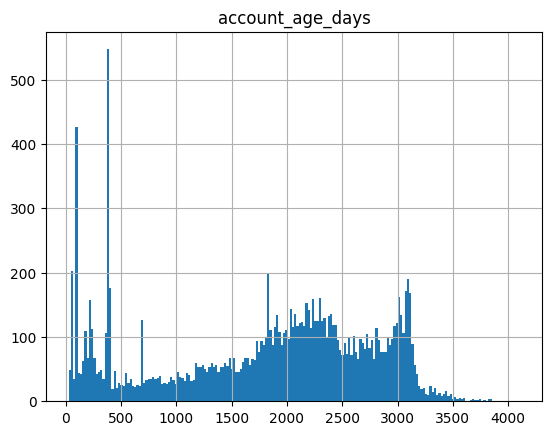

count    1.062000e+04
mean     1.757760e+03
std      4.493285e+04
min      0.000000e+00
25%      1.000000e+01
50%      4.000000e+01
75%      2.410000e+02
max      3.787842e+06
Name: followers_count, dtype: float64


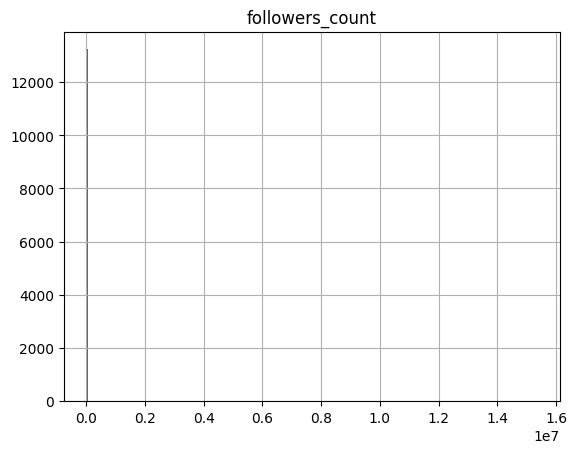

count     10620.000000
mean        394.032392
std        2427.584732
min           0.000000
25%           0.000000
50%          53.500000
75%         306.000000
max      148095.000000
Name: friends_count, dtype: float64


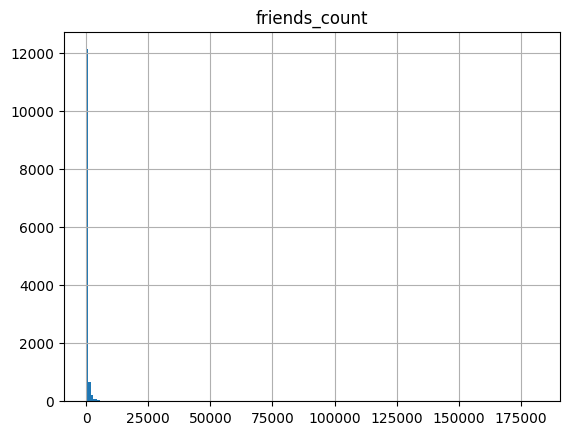

count    1.062000e+04
mean     1.015911e+04
std      4.766886e+04
min      4.000000e+00
25%      1.013000e+03
50%      2.527500e+03
75%      4.871500e+03
max      2.362464e+06
Name: statuses_count, dtype: float64


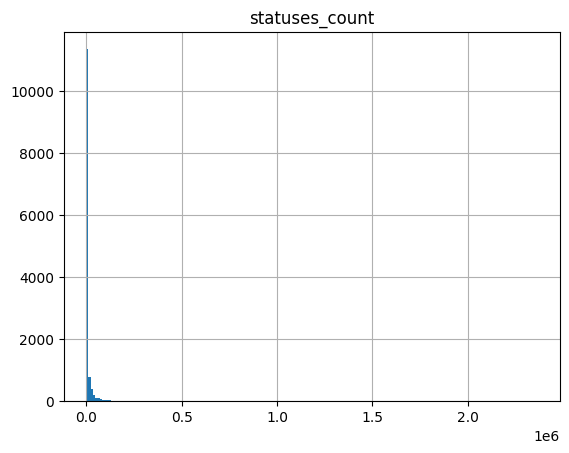

count     10620.000000
mean       5847.129379
std       18931.797787
min           0.000000
25%         562.000000
50%        1631.500000
75%        2595.000000
max      572806.000000
Name: favourites_count, dtype: float64


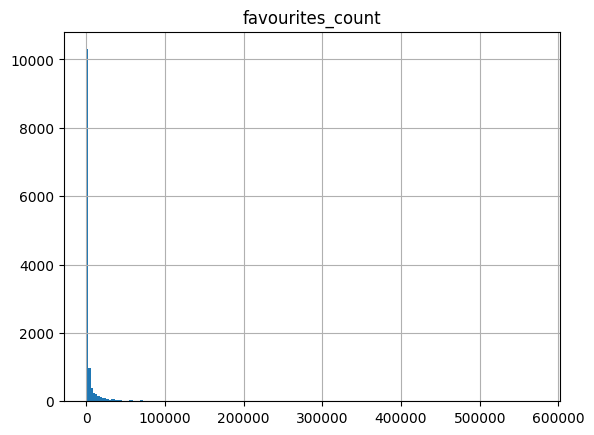

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in ['account_age_days', 'followers_count', 'friends_count', 'statuses_count', 'favourites_count']:
    print(X_train[col].describe())
    plt.title(col)
    df_cleaned[col].hist(bins=200)
    plt.show()



In [ ]:
print(X_train.columns.tolist())

['followers_count', 'friends_count', 'favourites_count', 'geo_enabled', 'statuses_count', 'profile_background_tile', 'profile_use_background_image', 'has_extended_profile', 'default_profile', 'has_description', 'has_location', 'has_default_bg_theme', 'has_added_url', 'has_profile_banner', 'account_age_days', 'lang_cat']


problem long tails, ale modele drzewiaste powinny sobie poradzic. Nie wykonuję na razie również np standaryzacji, bo skupiam się na modelach drzewiastych.

In [28]:
#OHE na zmienej kategorialnej lang_cat - wcześniej mniejsze kategorie wrzuciłam do 'other'
from sklearn.preprocessing import OneHotEncoder

# Inicjalizacja kodera
encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

# Dopasowanie kodera do zbioru treningowego i transformacja
X_train_encoded = encoder.fit_transform(X_train[['lang_cat']])

# Transformacja zbioru testowego przy użyciu kodera dopasowanego do train
X_test_encoded = encoder.transform(X_test[['lang_cat']])

# Pobranie nazw utworzonych kolumn
encoded_columns = encoder.get_feature_names_out(['lang_cat'])

# Konwersja do DataFrame
X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoded_columns,
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoded_columns,
    index=X_test.index
)

# Usunięcie oryginalnej zmiennej kategorycznej
X_train = X_train.drop(columns=['lang_cat'])
X_test = X_test.drop(columns=['lang_cat'])

# Połączenie zmiennych numerycznych i zakodowanej zmiennej lang_cat
X_train = pd.concat([X_train, X_train_encoded], axis=1)
X_test = pd.concat([X_test, X_test_encoded], axis=1)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, roc_auc_score
from sklearn.pipeline import make_pipeline

models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42), #jako baseline, żeby zobaczyć jak dobrą predykcję zrobi płytkie pojedyncze drzewo i móc porównać do tego złożone modele
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

for name, model in models.items():
    print(f"\n{name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(classification_report(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_proba))


In [ ]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

print("Random Forest best params:", grid_search_rf.best_params_)
print("Random Forest best CV ROC AUC:", grid_search_rf.best_score_)

#ewaluacja na zbiorze testowym (np. dla RF z najlepszymi parametrami)
best_rf = grid_search_rf.best_estimator_
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]
roc_auc_test_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"Random Forest test ROC AUC: {roc_auc_test_rf:.4f}")


In [ ]:
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid_search_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search_xgb.fit(X_train, y_train)

print("XGBoost best params:", grid_search_xgb.best_params_)
print("XGBoost best CV ROC AUC:", grid_search_xgb.best_score_)

best_xgb = grid_search_xgb.best_estimator_
y_pred_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
roc_auc_test_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"XGBoost test ROC AUC: {roc_auc_test_xgb:.4f}")

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    print(f"--- {model_name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"ROC AUC:   {roc_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"ROC Curve - {model_name}")
    plt.show()

In [ ]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

evaluate_model(dt, X_test, y_test, "Decision Tree")
evaluate_model(best_rf, X_test, y_test, "Random Forest")
evaluate_model(best_xgb, X_test, y_test, "XGBoost")

Minimalna poprawa po grid searchu. Można rozważyć rozszerzenie zestawu parametrów do tuningu, RandomizedSearch. Ale może to nie przynieść dużych zysków w jakości modeli. Ale obecne wyniki są bardzo zadowalające.